# Twin Axes Seaborn Histogram

This is a function that plots a histogram and the emperical cumulative distribution function of highly skewed values on different axis. It calculates the given or default quantiles of the feature to eliminate extream values to better view the data. The default binning method is square root, but the function can take any parameter the bins parameter in sns.hist() can take. This includes a set number like 25 or a list of thresholds.

In [114]:
import numpy as np 
import pandas as pd
import matplotlib as mpl 
from matplotlib import pyplot as plt
import pandas as pd

The data used here is fall enrollment data from the Integrated Postsecondary education Data System (IPEDS). This data describes fall enrollments for US colleges and universities. These values are typically highly positively skewed. 

In [163]:
df=pd.read_csv('https://nces.ed.gov/ipeds/datacenter/data/EF2023A.zip', compression='zip', encoding="ISO-8859-1") 

C:\Users\clair\AppData\Local\Temp\ipykernel_26944\4188228560.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


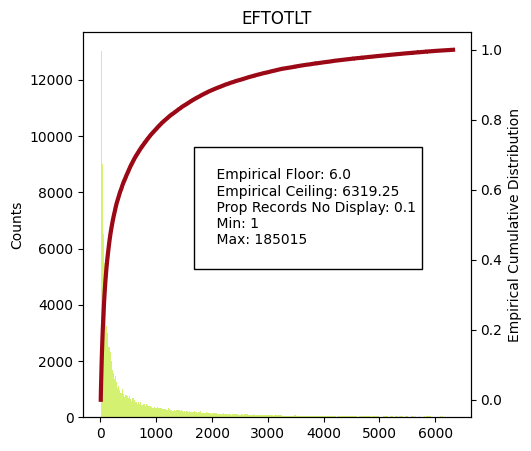

In [221]:
def my_func(df, feature, *dicts, binning='sqrt', f_q=0.05, c_q=0.95, text_x=0.3, text_y=0.4):
    # hist_dict needs to be before plot_dict in call then optional calls
    # f_q and c_q are floor and ceiling quantile to eliminate extreme values 
    # text_x and text_y are the coordinates of the bootom left corner of text box
    hist_dict = dicts[0] if len(dicts) > 0 else {'color':'#D5F171'} 
    plot_dict= dicts[1] if len(dicts) > 1 else {'color':'#9C0916', 'linewidth':3}

    feat_clean = df[feature].dropna()
    
    e_floor = feat_clean.quantile(f_q)
    e_ceiling = feat_clean.quantile(c_q)

    df2 =  df[(df[feature] >= e_floor) & (df[feature] <= e_ceiling)]
    to_plot = np.sort(df2[feature].dropna())

    if len(feat_clean) == 0: raise ValueError("No valid data")
    if len(to_plot) == 0: raise ValueError("No data after quantile filtering")
    
    prop_rec_no_dis = (len(feat_clean)-len(to_plot))/len(feat_clean)
    text = f'''
    Empirical Floor: {np.round(e_floor, 3)}
    Empirical Ceiling: {np.round(e_ceiling, 3)}
    Prop Records No Display: {np.round(prop_rec_no_dis, 3)}
    Min: {df[feature].min()}
    Max: {df[feature].max()}
    '''

    ecd = np.arange(1, len(to_plot)+1) / len(to_plot)

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.hist(to_plot, bins=binning, **hist_dict) 
    ax.set_ylabel('Counts')

    ax2 = ax.twinx()
    ax2.plot(to_plot, ecd, **plot_dict)
    ax2.text(text_x, text_y, text, transform=ax2.transAxes, ha='left', va='bottom', bbox={'facecolor': 'white', 'edgecolor':'black'})  
    ax2.set_title(feature)
    ax2.set_ylabel('Empirical Cumulative Distribution')
    return fig, ax

fig, ax = my_func(df, 'EFTOTLT')
fig.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_26944\3983898243.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


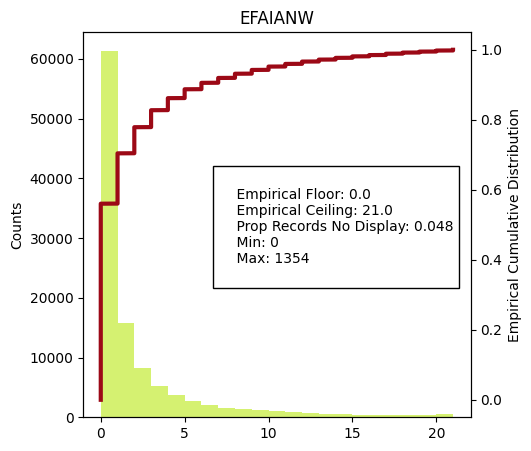

In [222]:
fig, ax = my_func(df, 'EFAIANW', f_q=0.0, c_q=0.95, text_x=0.35, text_y=0.35) 
fig.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_26944\3087090237.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


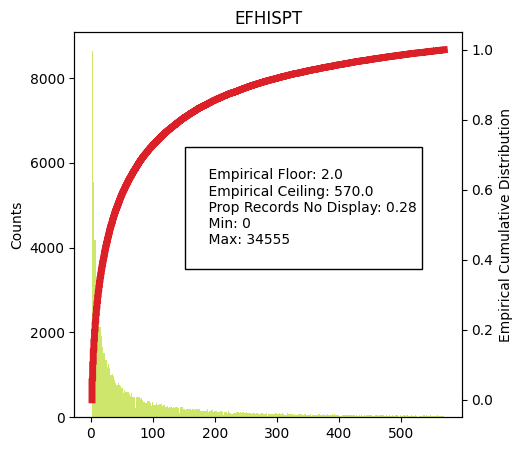

In [225]:
hist_dict = {'color':'#CEE66B'}
plot_dict = {'color':'#DB2127', 'linewidth':5}

# There are so many 0 in this feature I had to cut out 20% just to get a floor of 2
fig, ax = my_func(df, 'EFHISPT', hist_dict, plot_dict, f_q=0.20, c_q=0.90) 
fig.show()